In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import plotly.express as px
import matplotlib.patches as mpatches
from fractions import Fraction

y_cols = [
    'Stroke Work',
    'Stroke Volume',
    'Ejection Fraction',
    'Heart Rate',
    'Cardiac Output'
]


# Hemorrhage Level Graphs

In [6]:
def analyze_and_plot(file_path, y_cols):
    df = pd.read_excel(file_path)

    x_col = "True Hemorrhage Level"
    rate_col = "Hemorrhage Rate %/Time"

    tick_positions = [0, 10, 20, 30]
    tick_labels = [str(val) for val in tick_positions]

    def exp_func(x, a, b, c):
        return a * np.exp(b * x) + c

    for y_col in y_cols:
        if y_col not in df.columns:
            print(f"Column '{y_col}' not found in the data.")
            continue

        def get_grouped_stats(df_sub, use_median=False):
            grouped_stats = []
            for x_val, group in df_sub.groupby(x_col):
                y_vals = group[y_col].dropna()
                if len(y_vals) == 0:
                    continue
                center = np.median(y_vals) if use_median else np.mean(y_vals)
                std_dev = np.std(y_vals)
                filtered = y_vals[(y_vals >= center - 2*std_dev) & (y_vals <= center + 2*std_dev)]
                grouped_stats.append((x_val,
                                      filtered.mean() if len(filtered) > 0 else np.nan,
                                      filtered.median() if len(filtered) > 0 else np.nan,
                                      filtered.std() if len(filtered) > 1 else np.nan))
            stats_df = pd.DataFrame(grouped_stats, columns=[x_col, 'Mean', 'Median', 'Std'])
            return stats_df.dropna()

        stats_mean = get_grouped_stats(df, use_median=False)
        stats_median = get_grouped_stats(df, use_median=True)

        def fit_and_plot(stats_df, label_color, label_name, y_col_name):
            x_clean = stats_df[x_col]
            y_data = stats_df[y_col_name]

            if len(y_data) < 3:
                print(f"Not enough points for {y_col} ({label_name}) after outlier removal")
                return

            # Fit lines
            linear_coeffs = np.polyfit(x_clean, y_data, 1)
            quad_coeffs = np.polyfit(x_clean, y_data, 2)
            try:
                popt, _ = curve_fit(exp_func, x_clean, y_data, maxfev=10000)
                y_exp_pred = exp_func(x_clean, *popt)
                r2_exp = 1 - np.sum((y_data - y_exp_pred)**2) / np.sum((y_data - np.mean(y_data))**2)
            except RuntimeError:
                popt = [np.nan, np.nan, np.nan]
                r2_exp = np.nan

            ss_tot = np.sum((y_data - np.mean(y_data))**2)
            r2_linear = 1 - np.sum((y_data - np.polyval(linear_coeffs, x_clean))**2)/ss_tot
            r2_quad = 1 - np.sum((y_data - np.polyval(quad_coeffs, x_clean))**2)/ss_tot

            x_fit = np.linspace(min(x_clean), max(x_clean), 200)
            plt.figure(figsize=(9,7))

            # Boxplot
            data_by_bin = [df[df[x_col]==xv][y_col].dropna().values for xv in sorted(df[x_col].unique())]
            plt.boxplot(data_by_bin, positions=sorted(df[x_col].unique()), widths=1.5,
                        patch_artist=True, boxprops=dict(facecolor="lightgray", alpha=0.4))

            # Scatter points colored by exact values
            scatter_handles = []
            if rate_col in df.columns:
                float_rates = df[rate_col].astype(float)
                sc = plt.scatter(df[x_col], df[y_col],
                                 c=float_rates,
                                 cmap="viridis",
                                 alpha=0.7, s=50, edgecolor="k", zorder=3)

                # Legend using fractions with single-digit numerator/denominator
                rate_values = sorted(df[rate_col].unique())
                float_values = [float(f) for f in rate_values]
                min_val, max_val = min(float_values), max(float_values)
                for val in rate_values:
                    color_val = plt.cm.viridis((float(val) - min_val)/(max_val - min_val))
                    frac_label = Fraction(val).limit_denominator(9)  # max denominator = 9
                    scatter_handles.append(mpatches.Patch(color=color_val, label=f"Hemorrhage Rate {frac_label}"))
            else:
                plt.scatter(df[x_col], df[y_col], color="black", alpha=0.7, s=50, zorder=3)

            # Fit lines
            plt.plot(x_fit, np.polyval(linear_coeffs, x_fit), linestyle="--", color=label_color,
                     label=f"Linear (R²={r2_linear:.3f})", zorder=4)
            plt.plot(x_fit, np.polyval(quad_coeffs, x_fit), linestyle="-.", color=label_color,
                     label=f"Quadratic (R²={r2_quad:.3f})", zorder=4)
            if not np.isnan(popt[0]):
                plt.plot(x_fit, exp_func(x_fit, *popt), linestyle=":", color=label_color,
                         label=f"Exp (R²={r2_exp:.3f})", zorder=4)

            plt.xlabel('Hemorrhage Level')
            plt.ylabel(y_col)
            plt.title(f'{y_col} vs Hemorrhage Level ({label_name}, Outliers Removed)')
            plt.grid(True, linestyle="--", alpha=0.6)
            plt.xticks(tick_positions, tick_labels)
            plt.xlim(-2, 32)

            # Legend outside
            line_handles, line_labels = plt.gca().get_legend_handles_labels()
            plt.legend(handles=scatter_handles + line_handles,
                       loc='center left',
                       bbox_to_anchor=(1.02, 0.5),
                       borderaxespad=0)

            plt.tight_layout()
            plt.show()

            # Print equations
            print(f"--- {y_col} ({label_name}) ---")
            print(f"Linear:    y = {linear_coeffs[0]:.4f}x + {linear_coeffs[1]:.4f}     R² = {r2_linear:.4f}")
            print(f"Quadratic: y = {quad_coeffs[0]:.4f}x² + {quad_coeffs[1]:.4f}x + {quad_coeffs[2]:.4f}     R² = {r2_quad:.4f}")
            if not np.isnan(popt[0]):
                print(f"Exp:       y = {popt[0]:.4f} * exp({popt[1]:.4f}x) + {popt[2]:.4f}     R² = {r2_exp:.4f}")
            print()

        # Plot mean and median fits
        fit_and_plot(stats_mean, "blue", "Mean", "Mean")
        fit_and_plot(stats_median, "red", "Median", "Median")

        # Plotly scatter export
        if "Parent Folder" in df.columns:
            fig = px.scatter(df, x=x_col, y=y_col,
                             color=df[rate_col].astype(float) if rate_col in df.columns else None,
                             color_continuous_scale="viridis",
                             hover_data=["Parent Folder"],
                             title=f"{y_col} Scatter Plot (Interactive)")
            fig.update_traces(marker=dict(size=7, opacity=0.6))
            fig.write_html(f"{y_col}_scatter.html")
            fig.write_image(f"{y_col}_scatter.png")
            print(f"Saved Plotly scatter plots for {y_col} → HTML + PNG")


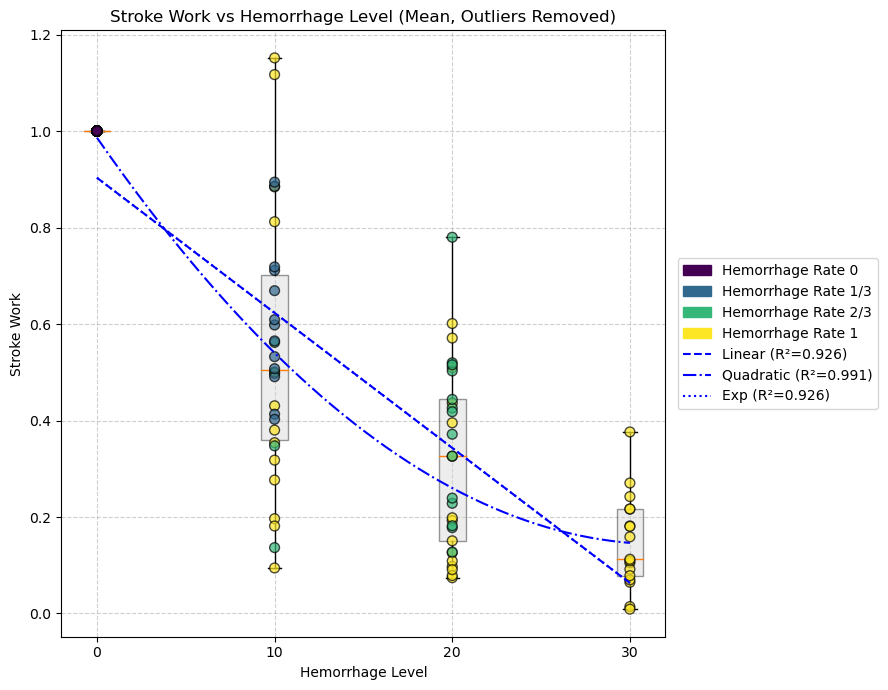

--- Stroke Work (Mean) ---
Linear:    y = -0.0280x + 0.9031     R² = 0.9258
Quadratic: y = 0.0008x² + -0.0529x + 0.9863     R² = 0.9911
Exp:       y = -2934.0782 * exp(0.0000x) + 2934.9814     R² = 0.9258



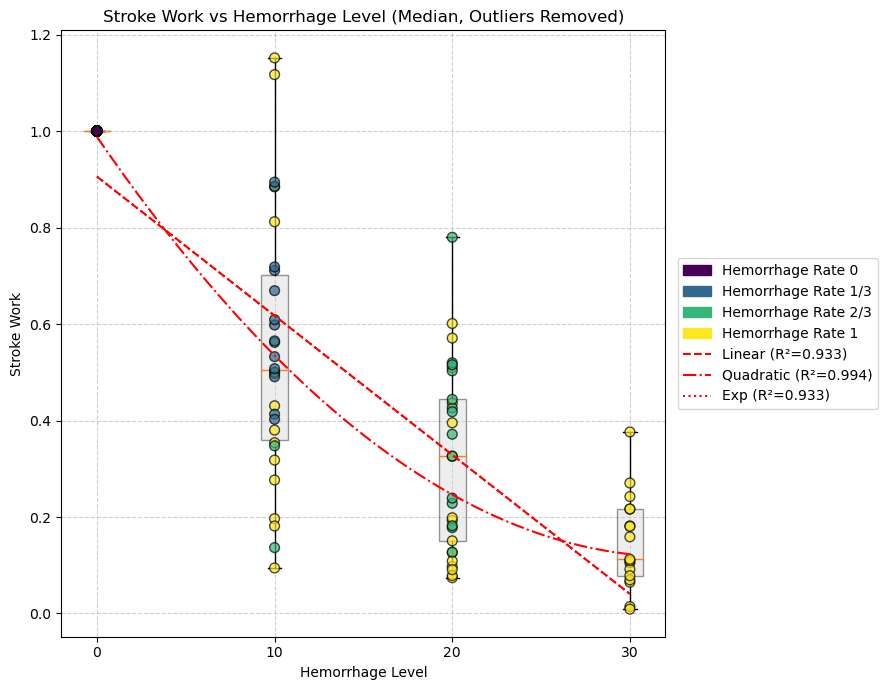

--- Stroke Work (Median) ---
Linear:    y = -0.0288x + 0.9056     R² = 0.9326
Quadratic: y = 0.0008x² + -0.0536x + 0.9880     R² = 0.9936
Exp:       y = -2521.4371 * exp(0.0000x) + 2522.3427     R² = 0.9326

Saved Plotly scatter plots for Stroke Work → HTML + PNG


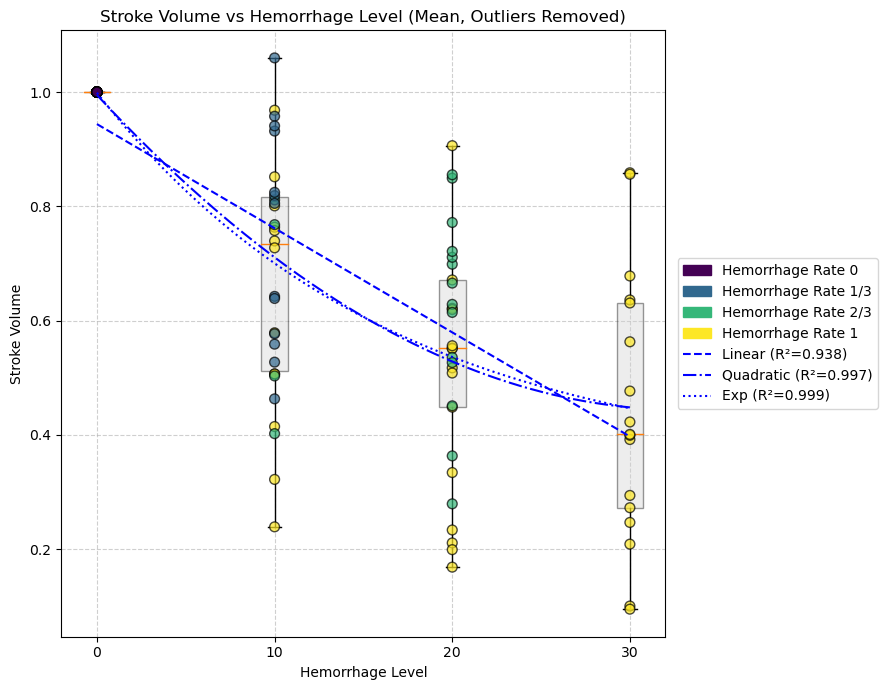

--- Stroke Volume (Mean) ---
Linear:    y = -0.0182x + 0.9439     R² = 0.9384
Quadratic: y = 0.0005x² + -0.0335x + 0.9949     R² = 0.9971
Exp:       y = 0.6617 * exp(-0.0600x) + 0.3373     R² = 0.9995



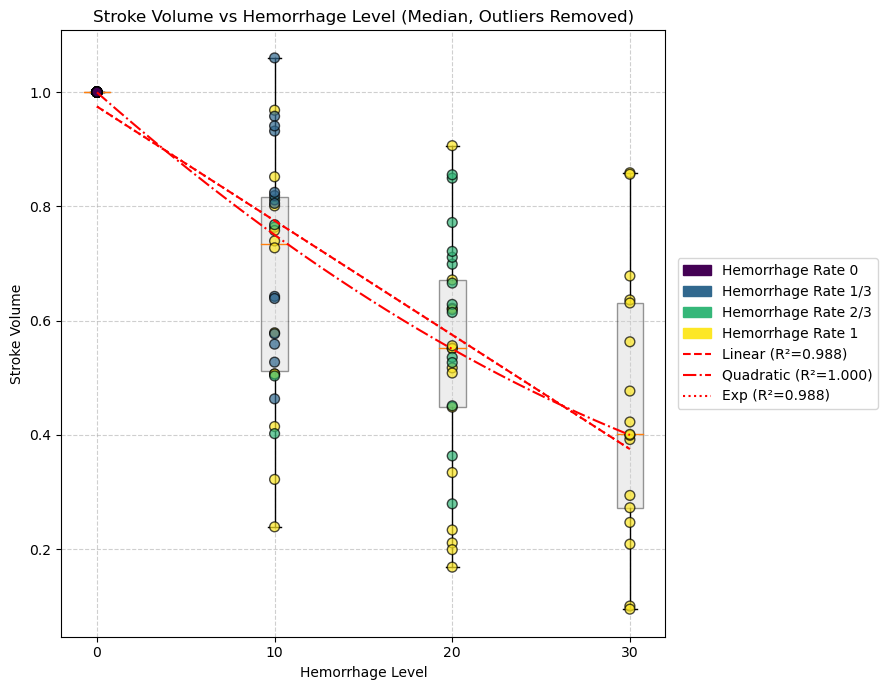

--- Stroke Volume (Median) ---
Linear:    y = -0.0200x + 0.9747     R² = 0.9879
Quadratic: y = 0.0002x² + -0.0274x + 0.9995     R² = 1.0000
Exp:       y = -2043.9659 * exp(0.0000x) + 2044.9407     R² = 0.9879

Saved Plotly scatter plots for Stroke Volume → HTML + PNG


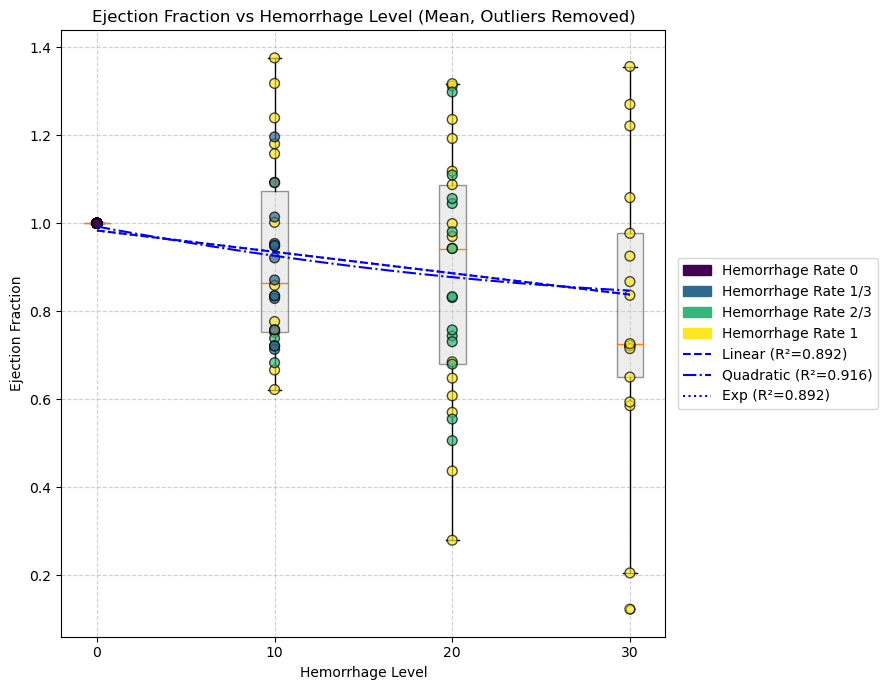

--- Ejection Fraction (Mean) ---
Linear:    y = -0.0049x + 0.9835     R² = 0.8916
Quadratic: y = 0.0001x² + -0.0076x + 0.9926     R² = 0.9162
Exp:       y = -426.3210 * exp(0.0000x) + 427.3045     R² = 0.8916



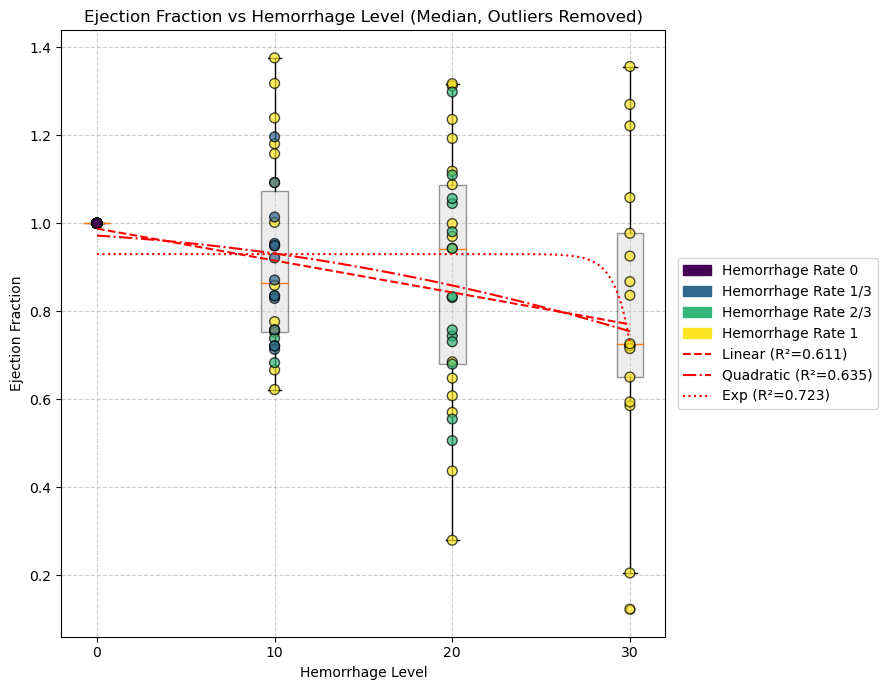

--- Ejection Fraction (Median) ---
Linear:    y = -0.0073x + 0.9878     R² = 0.6111
Quadratic: y = -0.0002x² + -0.0025x + 0.9720     R² = 0.6346
Exp:       y = -0.0000 * exp(1.1941x) + 0.9300     R² = 0.7225

Saved Plotly scatter plots for Ejection Fraction → HTML + PNG


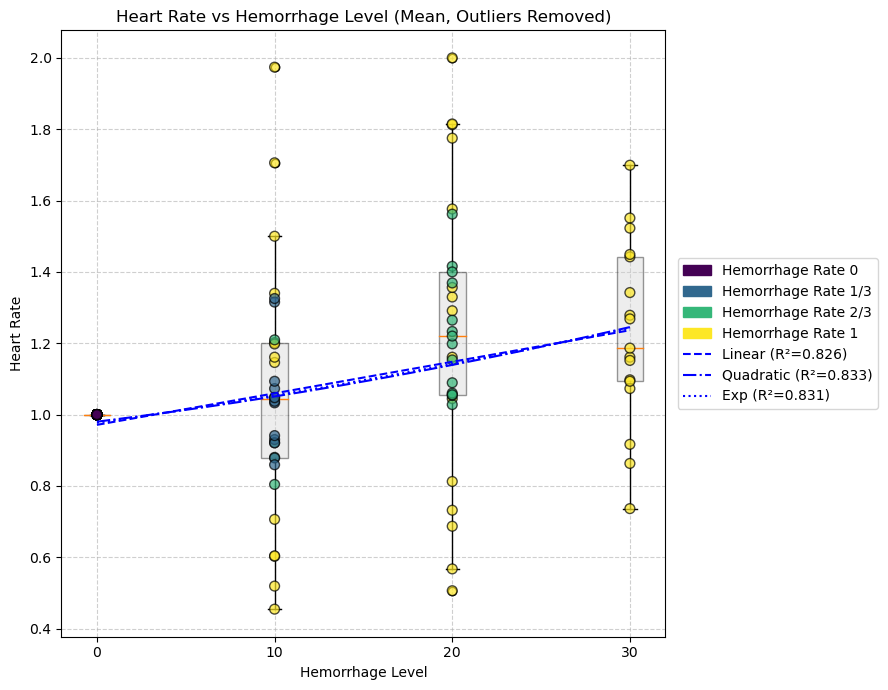

--- Heart Rate (Mean) ---
Linear:    y = 0.0088x + 0.9713     R² = 0.8260
Quadratic: y = 0.0001x² + 0.0062x + 0.9801     R² = 0.8326
Exp:       y = 0.5182 * exp(0.0138x) + 0.4589     R² = 0.8305



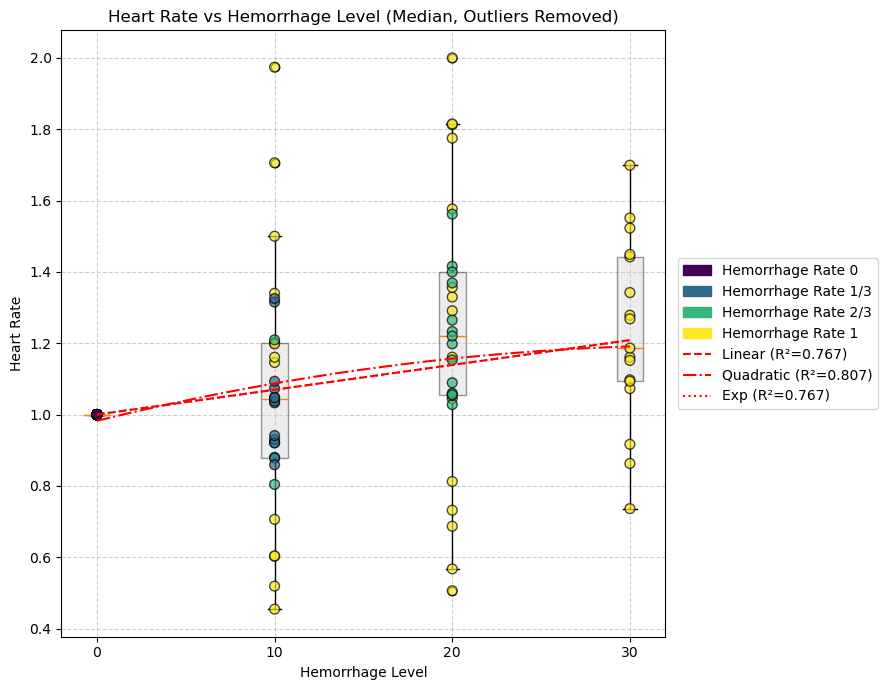

--- Heart Rate (Median) ---
Linear:    y = 0.0070x + 1.0002     R² = 0.7673
Quadratic: y = -0.0002x² + 0.0123x + 0.9826     R² = 0.8069
Exp:       y = 531.2865 * exp(0.0000x) + -530.2863     R² = 0.7673

Saved Plotly scatter plots for Heart Rate → HTML + PNG


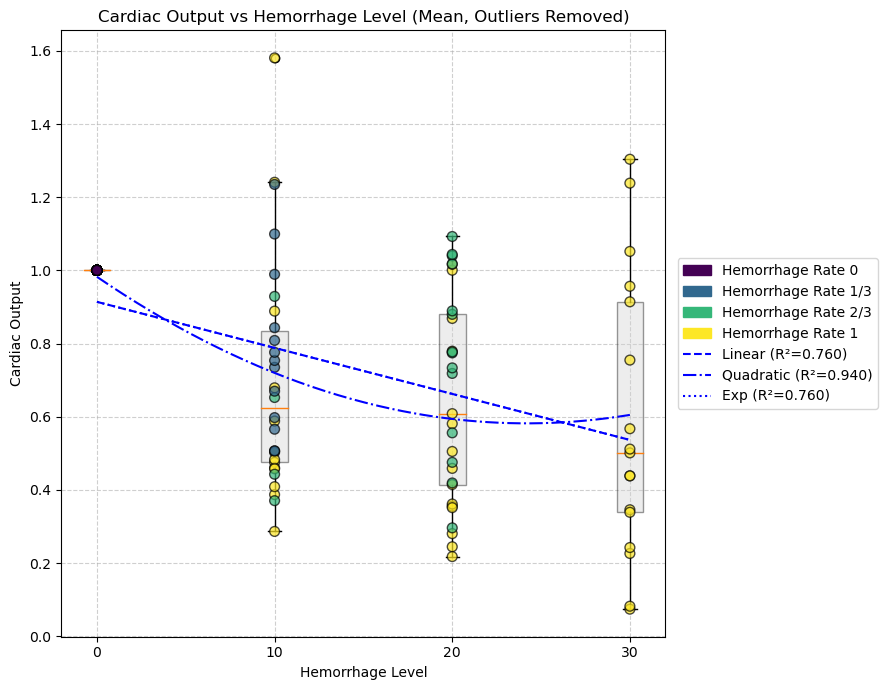

--- Cardiac Output (Mean) ---
Linear:    y = -0.0126x + 0.9139     R² = 0.7604
Quadratic: y = 0.0007x² + -0.0331x + 0.9824     R² = 0.9404
Exp:       y = -1040.0387 * exp(0.0000x) + 1040.9526     R² = 0.7603



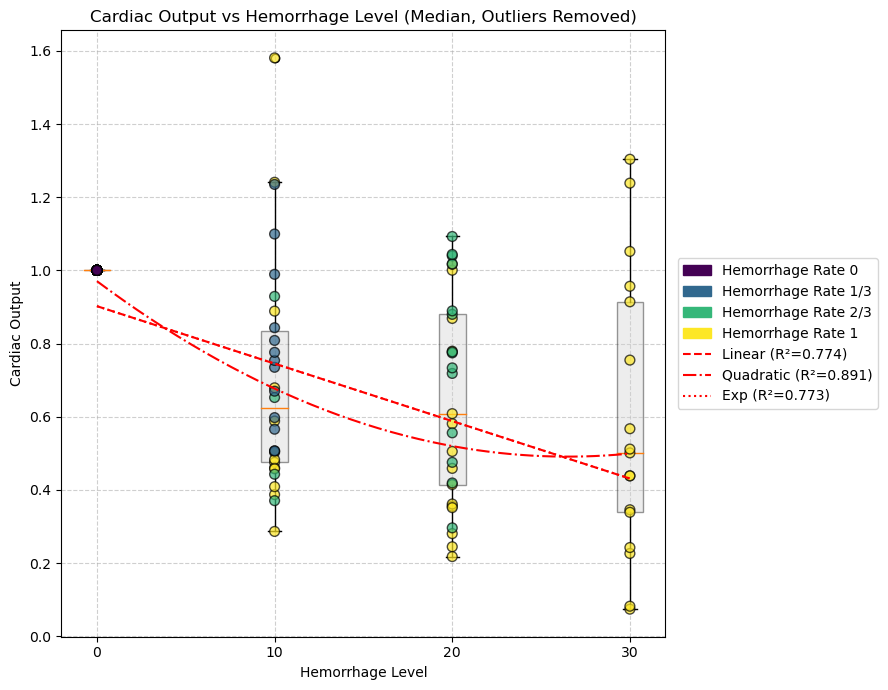

--- Cardiac Output (Median) ---
Linear:    y = -0.0157x + 0.9022     R² = 0.7735
Quadratic: y = 0.0007x² + -0.0362x + 0.9705     R² = 0.8905
Exp:       y = -1448.3433 * exp(0.0000x) + 1449.2454     R² = 0.7735

Saved Plotly scatter plots for Cardiac Output → HTML + PNG


In [7]:
analyze_and_plot('PV_Fractional_Increase_T0-1_cleaned.xlsx', y_cols)

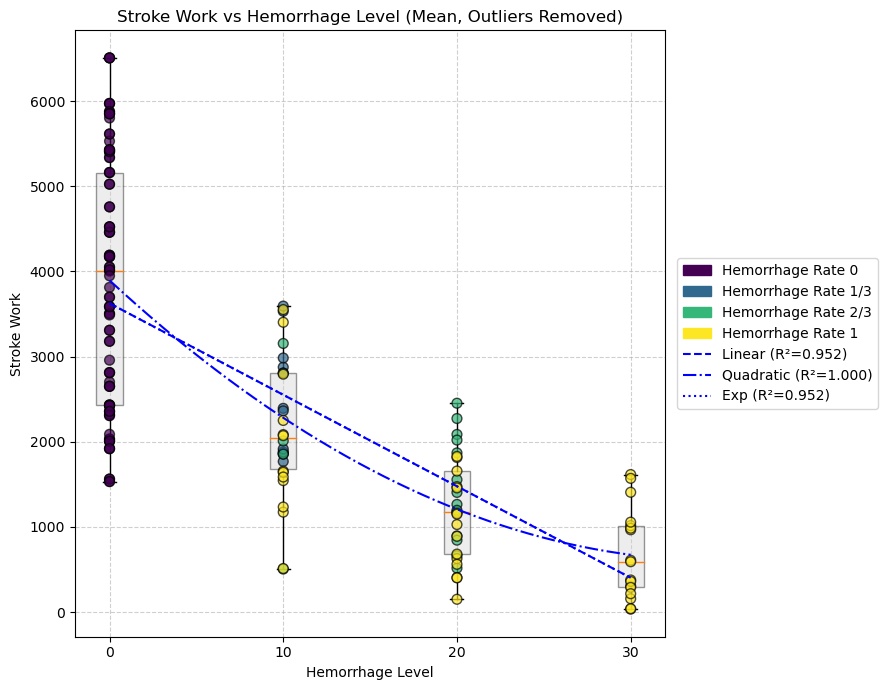

--- Stroke Work (Mean) ---
Linear:    y = -107.4172x + 3625.8559     R² = 0.9517
Quadratic: y = 2.6978x² + -188.3497x + 3895.6310     R² = 0.9997
Exp:       y = -8709691.0776 * exp(0.0000x) + 8713316.8290     R² = 0.9517



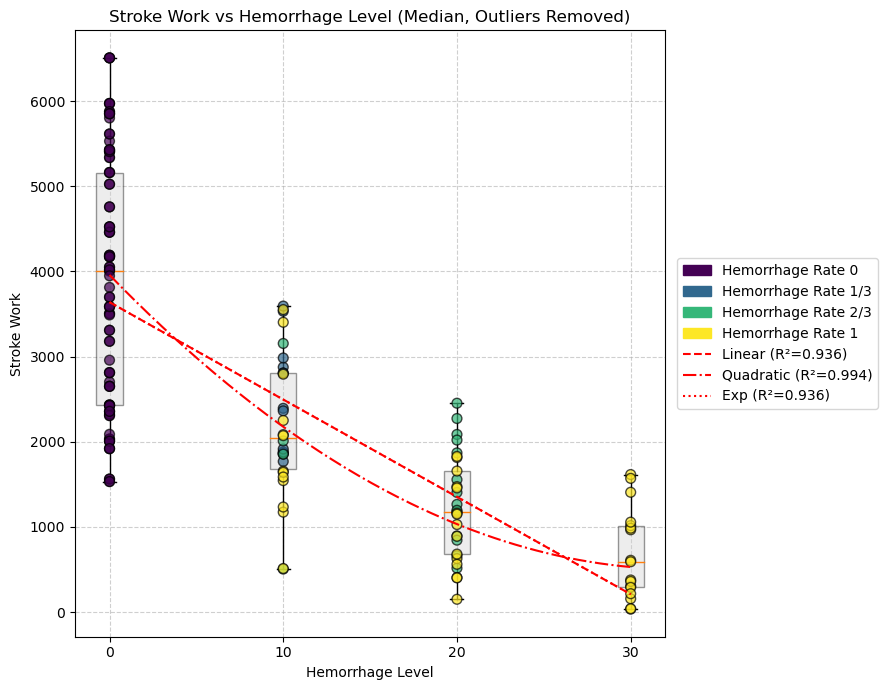

--- Stroke Work (Median) ---
Linear:    y = -114.3133x + 3639.1943     R² = 0.9357
Quadratic: y = 3.1959x² + -210.1899x + 3958.7829     R² = 0.9942
Exp:       y = -11571733.3705 * exp(0.0000x) + 11575372.4874     R² = 0.9356

Saved Plotly scatter plots for Stroke Work → HTML + PNG


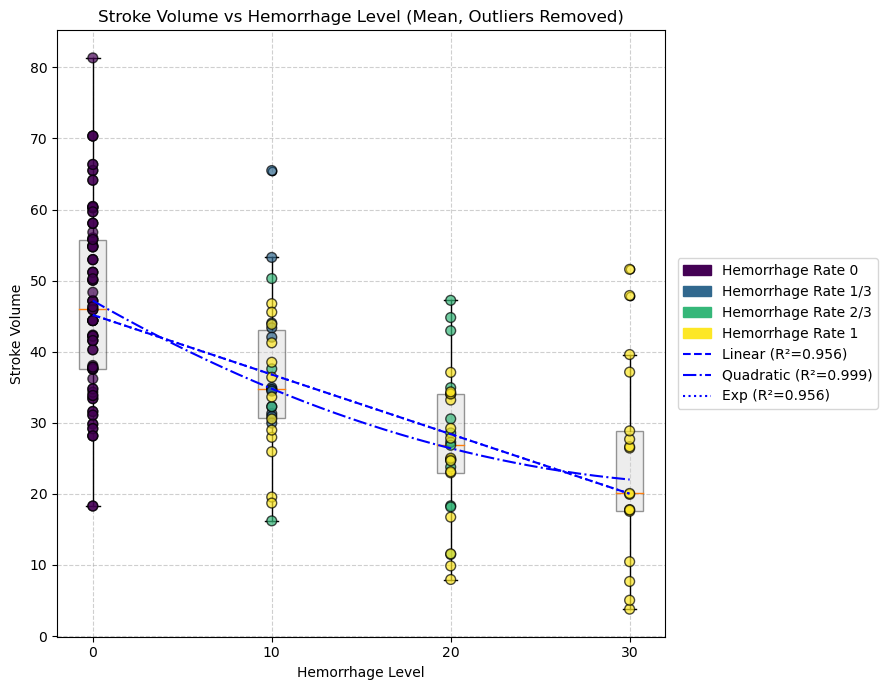

--- Stroke Volume (Mean) ---
Linear:    y = -0.8387x + 45.1778     R² = 0.9558
Quadratic: y = 0.0200x² + -1.4380x + 47.1756     R² = 0.9991
Exp:       y = -67887.0717 * exp(0.0000x) + 67932.2487     R² = 0.9557



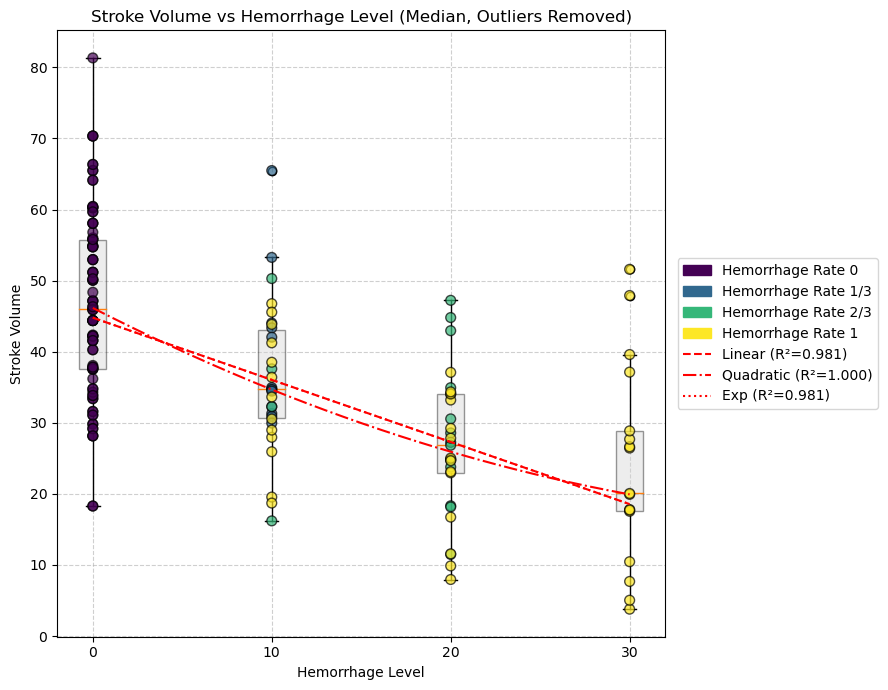

--- Stroke Volume (Median) ---
Linear:    y = -0.8743x + 44.7841     R² = 0.9807
Quadratic: y = 0.0137x² + -1.2853x + 46.1541     R² = 1.0000
Exp:       y = -70659.6823 * exp(0.0000x) + 70704.4656     R² = 0.9807

Saved Plotly scatter plots for Stroke Volume → HTML + PNG


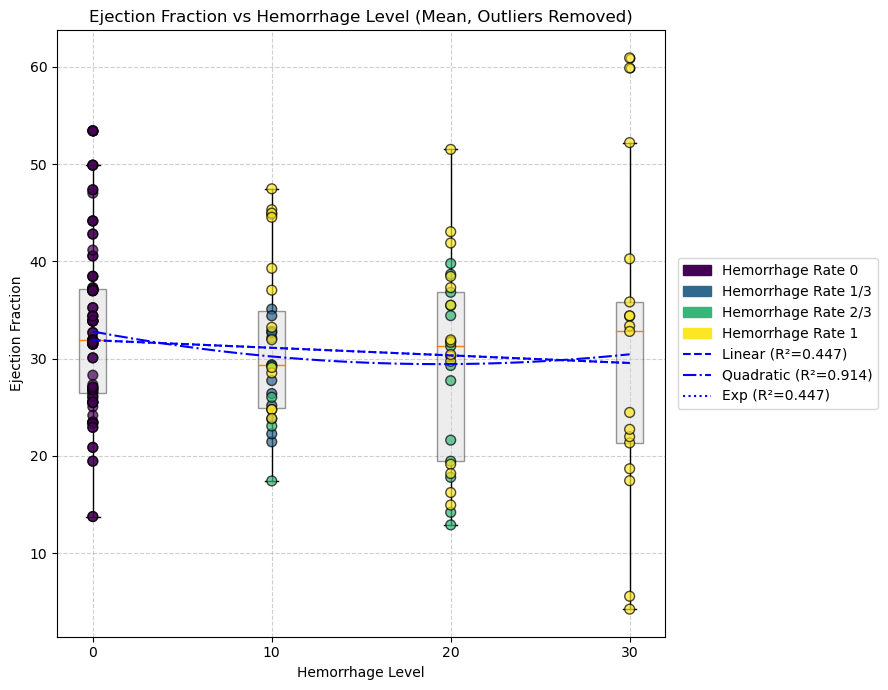

--- Ejection Fraction (Mean) ---
Linear:    y = -0.0782x + 31.8900     R² = 0.4467
Quadratic: y = 0.0089x² + -0.3464x + 32.7842     R² = 0.9145
Exp:       y = -8396.3286 * exp(0.0000x) + 8428.2185     R² = 0.4467



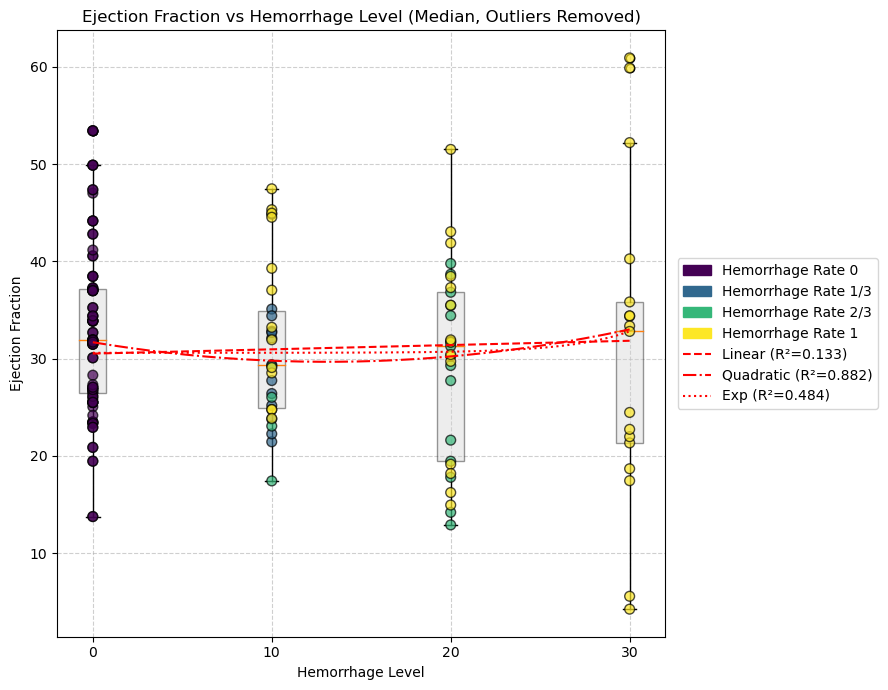

--- Ejection Fraction (Median) ---
Linear:    y = 0.0440x + 30.5108     R² = 0.1329
Quadratic: y = 0.0117x² + -0.3066x + 31.6798     R² = 0.8817
Exp:       y = 0.0003 * exp(0.2940x) + 30.5886     R² = 0.4837

Saved Plotly scatter plots for Ejection Fraction → HTML + PNG


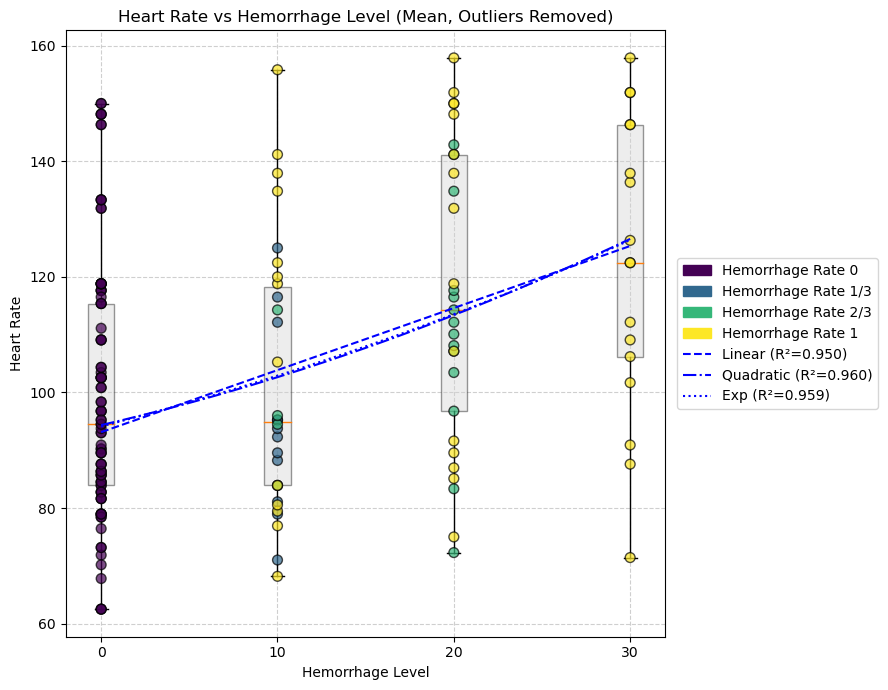

--- Heart Rate (Mean) ---
Linear:    y = 1.0739x + 93.1284     R² = 0.9504
Quadratic: y = 0.0122x² + 0.7071x + 94.3510     R² = 0.9602
Exp:       y = 42.2719 * exp(0.0189x) + 51.8370     R² = 0.9585



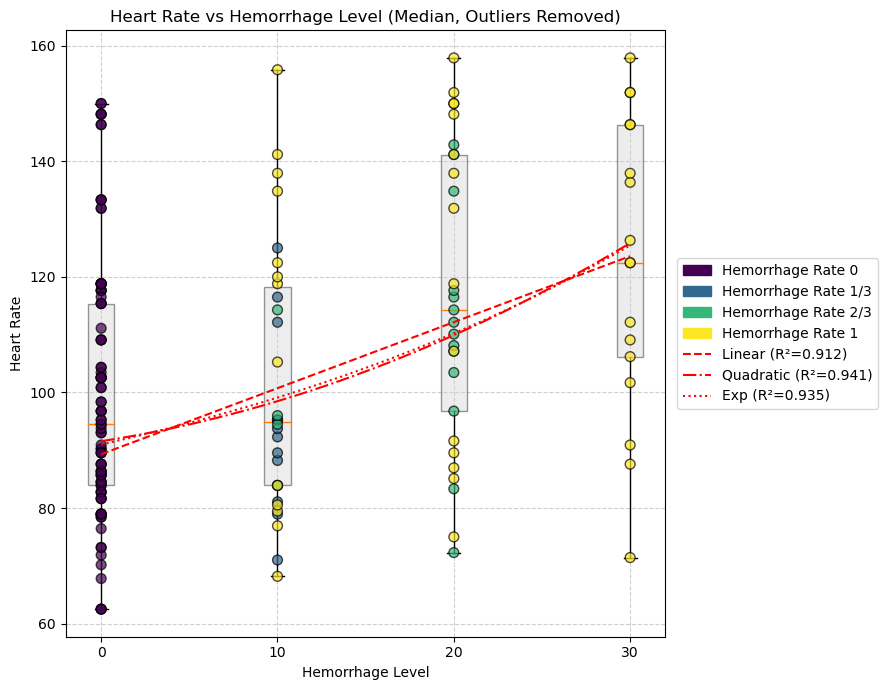

--- Heart Rate (Median) ---
Linear:    y = 1.1424x + 89.3160     R² = 0.9123
Quadratic: y = 0.0225x² + 0.4674x + 91.5662     R² = 0.9406
Exp:       y = 21.9982 * exp(0.0314x) + 68.9946     R² = 0.9348

Saved Plotly scatter plots for Heart Rate → HTML + PNG


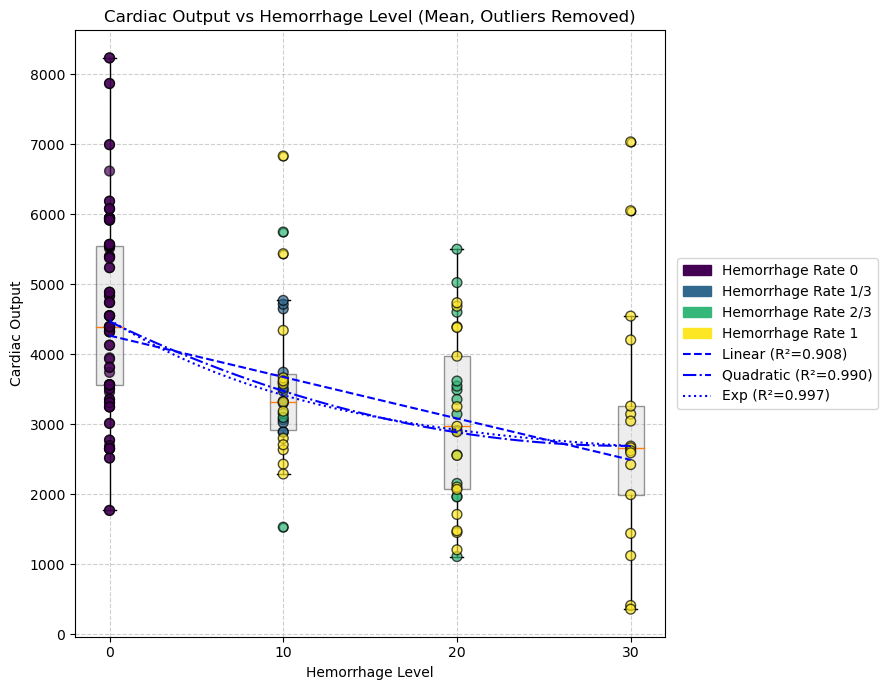

--- Cardiac Output (Mean) ---
Linear:    y = -59.1807x + 4267.8416     R² = 0.9077
Quadratic: y = 1.9967x² + -119.0821x + 4467.5130     R² = 0.9903
Exp:       y = 1999.5892 * exp(-0.0771x) + 2492.2911     R² = 0.9974



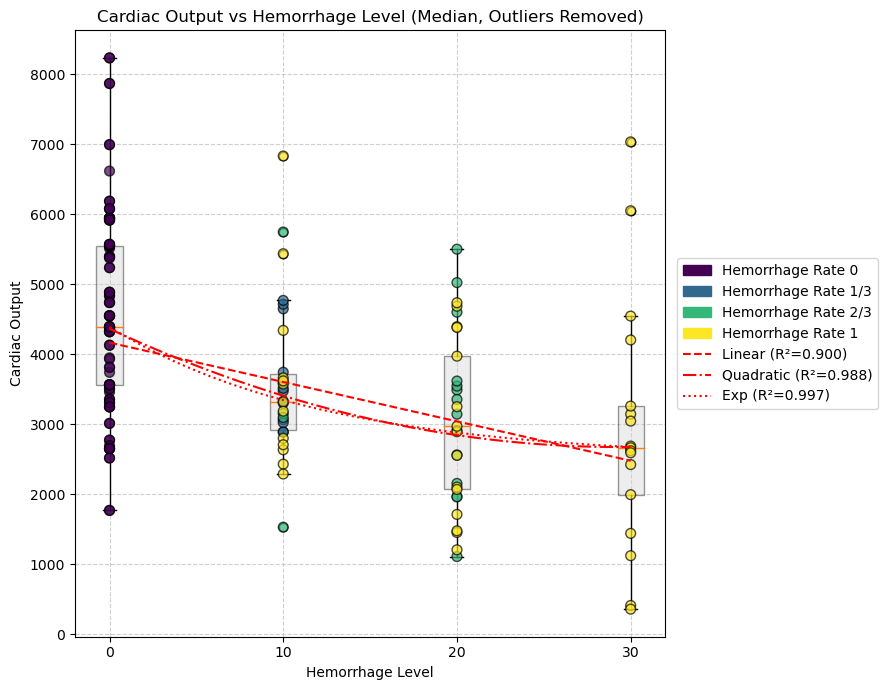

--- Cardiac Output (Median) ---
Linear:    y = -56.2668x + 4167.7207     R² = 0.9002
Quadratic: y = 1.9680x² + -115.3065x + 4364.5196     R² = 0.9882
Exp:       y = 1879.2517 * exp(-0.0811x) + 2511.1644     R² = 0.9967

Saved Plotly scatter plots for Cardiac Output → HTML + PNG


In [8]:
analyze_and_plot('PV_Performance_cleaned.xlsx', y_cols)

# Hemorrhage Level

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import plotly.express as px
import matplotlib.patches as mpatches

def analyze_and_plot(file_path, y_cols):
    """
    Analyze and plot mean/median trends with linear, quadratic, and exponential fits,
    alongside scatter + boxplot visualization.
    Outliers beyond 2 std dev from the mean/median are removed from raw data before computing stats.
    X-axis = Hemorrhage Rate %/Time (normalized).
    Points are colored by Hemorrhage Level (discrete values).
    """

    df = pd.read_excel(file_path)

    x_col = "Hemorrhage Rate %/Time"
    level_col = "Hemorrhage Level"  # Column for coloring

    # Normalize x-axis
    x_min, x_max = df[x_col].min(), df[x_col].max()
    df['Normalized X'] = (df[x_col] - x_min) / (x_max - x_min)

    tick_positions = [0.0, 1/3, 2/3, 1.0]
    tick_labels = ['0', '1/3', '2/3', '1']

    # Map Hemorrhage Level to discrete colors
    if level_col in df.columns:
        level_values = sorted(df[level_col].unique())
        level_colors = {val: plt.cm.tab10(i / max(len(level_values)-1,1)) for i, val in enumerate(level_values)}

    def exp_func(x, a, b, c):
        return a * np.exp(b * x) + c

    for y_col in y_cols:
        if y_col not in df.columns:
            print(f"Column '{y_col}' not found in the data.")
            continue

        # --- Function to remove outliers and compute grouped stats ---
        def get_grouped_stats(df_sub, use_median=False):
            grouped_stats = []
            for x_val, group in df_sub.groupby('Normalized X'):
                y_vals = group[y_col].dropna()
                if len(y_vals) == 0:
                    continue
                center = np.median(y_vals) if use_median else np.mean(y_vals)
                std_dev = np.std(y_vals)
                filtered = y_vals[(y_vals >= center - 2*std_dev) & (y_vals <= center + 2*std_dev)]
                grouped_stats.append((x_val,
                                      filtered.mean() if len(filtered) > 0 else np.nan,
                                      filtered.median() if len(filtered) > 0 else np.nan,
                                      filtered.std() if len(filtered) > 1 else np.nan))
            stats_df = pd.DataFrame(grouped_stats, columns=['Normalized X', 'Mean', 'Median', 'Std'])
            return stats_df.dropna()

        stats_mean = get_grouped_stats(df, use_median=False)
        stats_median = get_grouped_stats(df, use_median=True)

        def fit_and_plot(stats_df, label_color, label_name, y_col_name):
            x_clean = stats_df['Normalized X']
            y_data = stats_df[y_col_name]

            if len(y_data) < 3:
                print(f"Not enough points for {y_col} ({label_name}) after outlier removal")
                return

            # Fit lines
            linear_coeffs = np.polyfit(x_clean, y_data, 1)
            quad_coeffs = np.polyfit(x_clean, y_data, 2)
            try:
                popt, _ = curve_fit(exp_func, x_clean, y_data, maxfev=10000)
                y_exp_pred = exp_func(x_clean, *popt)
                r2_exp = 1 - np.sum((y_data - y_exp_pred)**2) / np.sum((y_data - np.mean(y_data))**2)
            except RuntimeError:
                popt = [np.nan, np.nan, np.nan]
                r2_exp = np.nan

            ss_tot = np.sum((y_data - np.mean(y_data))**2)
            r2_linear = 1 - np.sum((y_data - np.polyval(linear_coeffs, x_clean))**2)/ss_tot
            r2_quad = 1 - np.sum((y_data - np.polyval(quad_coeffs, x_clean))**2)/ss_tot

            x_fit = np.linspace(0, 1, 200)
            plt.figure(figsize=(9,7))

            # Boxplot grouped by normalized x
            data_by_bin = [df[df['Normalized X']==xv][y_col].dropna().values for xv in sorted(df['Normalized X'].unique())]
            plt.boxplot(data_by_bin, positions=sorted(df['Normalized X'].unique()), widths=0.03,
                        patch_artist=True, boxprops=dict(facecolor="lightgray", alpha=0.4))

            # Scatter colored by Hemorrhage Level
            scatter_handles = []
            if level_col in df.columns:
                for lvl, color in level_colors.items():
                    sub_df = df[df[level_col]==lvl]
                    if len(sub_df) == 0:
                        continue
                    plt.scatter(sub_df['Normalized X'], sub_df[y_col], color=color, alpha=0.7, s=50, edgecolor='k', zorder=3)
                    scatter_handles.append(mpatches.Patch(color=color, label=f"Level {lvl}"))

            # Plot fit lines
            plt.plot(x_fit, np.polyval(linear_coeffs, x_fit), linestyle="--", color=label_color,
                     label=f"Linear (R²={r2_linear:.3f})", zorder=4)
            plt.plot(x_fit, np.polyval(quad_coeffs, x_fit), linestyle="-.", color=label_color,
                     label=f"Quadratic (R²={r2_quad:.3f})", zorder=4)
            if not np.isnan(popt[0]):
                plt.plot(x_fit, exp_func(x_fit, *popt), linestyle=":", color=label_color,
                         label=f"Exp (R²={r2_exp:.3f})", zorder=4)

            plt.xlabel('Hemorrhage Rate %/Time (Normalized)')
            plt.ylabel(y_col)
            plt.title(f'{y_col} vs Hemorrhage Rate %/Time ({label_name}, Outliers Removed)')
            plt.grid(True, linestyle="--", alpha=0.6)
            plt.xticks(tick_positions, tick_labels)
            plt.xlim(-0.05, 1.05)

            # Legend outside
            line_handles, line_labels = plt.gca().get_legend_handles_labels()
            plt.legend(handles=scatter_handles + line_handles,
                       loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

            plt.tight_layout()
            plt.show()

            # Print equations
            print(f"--- {y_col} ({label_name}) ---")
            print(f"Linear:    y = {linear_coeffs[0]:.4f}x + {linear_coeffs[1]:.4f}     R² = {r2_linear:.4f}")
            print(f"Quadratic: y = {quad_coeffs[0]:.4f}x² + {quad_coeffs[1]:.4f}x + {quad_coeffs[2]:.4f}     R² = {r2_quad:.4f}")
            if not np.isnan(popt[0]):
                print(f"Exp:       y = {popt[0]:.4f} * exp({popt[1]:.4f}x) + {popt[2]:.4f}     R² = {r2_exp:.4f}")
            print()

        # Plot mean and median fits
        fit_and_plot(stats_mean, "blue", "Mean", "Mean")
        fit_and_plot(stats_median, "red", "Median", "Median")

        # Plotly scatter export
        if "Parent Folder" in df.columns:
            fig = px.scatter(df, x='Normalized X', y=y_col, color=level_col if level_col in df.columns else None,
                             hover_data=["Parent Folder"],
                             color_discrete_map=level_colors if level_col in df.columns else None,
                             title=f"{y_col} Scatter Plot (Interactive)")
            fig.update_traces(marker=dict(size=7, opacity=0.6))
            fig.write_html(f"{y_col}_scatter.html")
            fig.write_image(f"{y_col}_scatter.png")
            print(f"Saved Plotly scatter plots for {y_col} → HTML + PNG")


In [ ]:
analyze_and_plot('PV_Fractional_Increase_T0-1_cleaned.xlsx', y_cols)

In [ ]:
analyze_and_plot('PV_Performance_cleaned.xlsx', y_cols)